# Аналитическая структура алгоритма SGP4

## 1. Введение и историческая справка

### 1.1. Контекст разработки алгоритма

Развитие полуаналитических методов моделирования движения искусственных спутников Земли (ИСЗ) в 1950-1970-х годах определялось вычислительными ограничениями электронно-вычислительных машин (ЭВМ) первого и второго поколений. Численное интегрирование уравнений движения в оскулирующих элементах требовало значительных затрат машинного времени, что ограничивало возможности оперативного ведения каталогов, содержащих большое количество космических объектов.

Решением данной проблемы стало создание общих теорий возмущений (*General Perturbations*), в которых дифференциальные уравнения движения интегрируются аналитически в рамках принятых допущений. Алгоритм **SGP4 (Simplified General Perturbations 4)** представляет собой математическую модель, сформировавшуюся в результате последовательной модификации нескольких фундаментальных подходов небесной механики:

1. **Теория Брауэра:** Математическим базисом SGP4 является аналитическое решение задачи о движении ИСЗ в гравитационном поле сфероидальной Земли, полученное Д. Брауэром [Brouwer, 1959]. Решение построено методом фон Цейпеля в канонических переменных Делоне и учитывает зональные гармоники геопотенциала до $J_5$.
2. **Модификация Лайддена:** Оригинальные формулы Брауэра содержали математические сингулярности (делители вида $e$ и $\sin i$) при малых эксцентриситетах и малых наклонениях орбиты. Р. Лайдден пересчитал вековые и периодические возмущения первого порядка в модифицированных переменных Пуанкаре [Lyddane, 1963], устранив особенности для околокруговых и экваториальных орбит.
3. **Модель Лейна-Крэнфорда:** Х. Лейн и К. Крэнфорд интегрировали в аналитическую теорию Брауэра влияние неконсервативных сил. Они разработали математическую модель изменений элементов под воздействием атмосферного торможения [Lane, 1969], основанную на степенном и экспоненциальном распределении плотности верхней атмосферы.
4. **Унификация SGP4:** К. Крэнфорд объединил указанные подходы в единый алгоритм, предназначенный для программной реализации. В 1980 году Командование аэрокосмической обороны Северной Америки (NORAD) официально опубликовало данную математическую модель в техническом отчете [Hoots, 1980].

Алгоритм SGP4 оперирует специфическим набором средних элементов орбиты - двухстрочными элементами (**TLE - Two-Line Elements**). Данные элементы не являются классическими средними элементами Кеплера, поскольку процедура их определения по траекторным измерениям неразрывно связана с математической структурой самого алгоритма SGP4.

### 1.2. Состав учитываемых возмущений

Алгоритм SGP4 разработан для моделирования движения космических объектов на низких околоземных орбитах (с периодом обращения менее 225 минут) на интервалах времени порядка нескольких суток [Hoots, 1980]. В математическую модель включены только те возмущающие факторы, которые вызывают макроскопические изменения траектории на указанном масштабе времени.

В SGP4 учитываются следующие физические факторы и их компоненты:

1. **Возмущения от нецентральности гравитационного поля Земли (Зональные гармоники):**
   * **Гармоника $J_2$ (Второй зональный коэффициент):** Определяет сплюснутость Земли. Вызывает вековую прецессию плоскости орбиты (линейное изменение долготы восходящего узла $h$ и аргумента перицентра $g$), а также порождает короткопериодические и долгопериодические колебания элементов. В алгоритме SGP4 гармоника $J_2$ учитывается до второго порядка малости ($J_2^2$).
   * **Гармоники $J_3$ и $J_4$:** Учитывают асимметрию северного и южного полушарий («грушевидность» Земли) и четвертую зональную гармонику геопотенциала. Порождают долгопериодические возмущения элементов с периодом, равным периоду обращения перицентра. Учитываются в первом порядке малости [Brouwer, 1959].

2. **Неконсервативные возмущения (Атмосферное торможение):**
   * **Вековые изменения элементов:** Моделируют монотонное уменьшение большой полуоси $a$ и эксцентриситета $e$, а также соответствующее ускорение средней аномалии $l$ под действием силы лобового сопротивления воздуха.
   * **Периодические возмущения от торможения:** Учитывают изменение плотности атмосферы по высоте в окрестности перигея. Выражаются через аналитические ряды по степеням эксцентриситета вплоть до пятого порядка [Lane, 1969].

### Факторы, исключенные из базового алгоритма SGP4:
* **Тессеральные и секторальные гармоники геопотенциала:** Долготная неоднородность гравитационного поля Земли в SGP4 игнорируется. Для нерезонансных орбит эти возмущения носят короткопериодический характер и имеют малую амплитуду.
* **Гравитационные возмущения от Луны и Солнца:** Притяжение внешних тел не учитывается, так как на низких орбитах его вклад за период прогноза незначителен.
* **Давление солнечного излучения:** Исключено из модели ввиду малого влияния на траекторию низкоорбитальных объектов по сравнению с атмосферным торможением.

*Примечание:* Учет тессеральных гармоник (для суточных и полусуточных резонансов) и лунно-солнечных возмущений реализован в глубококосмическом расширении алгоритма - **SDP4 (Simplified Deep Space Perturbations 4)** [Hoots, 1980].

### 1.3. Системы координат и шкалы времени в алгоритме SGP4

### Геоцентрическая система координат TEME
Выходные векторы положения и скорости ИСЗ рассчитываются в геоцентрической квазиинерциальной системе координат **TEME (True Equator, Mean Equinox - истинный экватор, среднее равноденствие)** [Hoots, 1981]:
* **Ось $Z$** направлена вдоль оси вращения Земли, положение которой определяется истинным географическим полюсом (с учетом прецессии и нутации на текущую эпоху).
* **Ось $X$** направлена в точку весеннего равноденствия, положение которой зафиксировано на среднюю эпоху формирования теории возмущений (модель IAU-1976/FK5) без учета ее нутационных колебаний.
* **Ось $Y$** дополняет систему до правой.

Поскольку ось $Z$ испытывает нутационные смещения, а ось $X$ очищена от них, система координат TEME не является строго инерциальной. Для сопоставления координат ИСЗ с системами координат общего назначения (например, ITRS/WGS-84) требуется внешний пересчет векторов из TEME через звездное время Гринвича (GMST) и параметры ориентации Земли (EOP).

### Шкалы времени и проблема секунд координации
Основным аргументом времени во всех аналитических полиномах SGP4 является временной интервал $\Delta t = t - t_0$ (в минутах), прошедший с момента эпохи TLE.

* **Шкала UTC (Всемирное координированное время):** Эпоха TLE фиксируется в гражданской шкале времени UTC.
* **Математическое допущение алгоритма:** Уравнения движения ИСЗ построены в предположении непрерывного течения времени (эквивалентно шкале Международного атомного времени TAI или Земного времени TT) [Hoots, 1980]. Алгоритм SGP4 не содержит внутренних механизмов учета секунд координации (*leap seconds*). 

Если интервал прогнозирования $\Delta t$ пересекает дату внедрения секунды координации, расчет разности гражданского времени приводит к кинематической ошибке (сдвигу ИСЗ вдоль орбиты на величину порядка $7.5$ км). В программных реализациях перед вычислением $\Delta t$ аргументы времени переводятся в непрерывную форму (через юлианские дни в шкале TT или TAI) с последующим вычитанием накопленных секунд координации [Hoots, 1981].

## 2. Математическая постановка задачи

Математическая формулировка алгоритма SGP4 строится на разделении консервативных (гравитационных) и неконсервативных (диссипативных) возмущений. 

### 2.1. Гамильтонова часть задачи (Гравитационные возмущения)

Для исследования гравитационных возмущений, вызванных несферичностью Земли, используется переход от декартовых координат к каноническим переменным Делоне $(l, g, h, L, G, H)$. Данные переменные связаны с классическими элементами Кеплера $(a, e, i, M, \omega, \Omega)$ следующими соотношениями:

$$
\begin{aligned}
l &= M && L = \sqrt{\mu a} \\
g &= \omega && G = L\sqrt{1 - e^2} \\
h &= \Omega && H = G\cos i
\end{aligned}
$$

где $\mu$ - геоцентрическая гравитационная постоянная. В этих переменных уравнения движения спутника в консервативном силовом поле являются каноническими уравнениями Гамильтона:

$$
\frac{d(l, g, h)}{dt} = \frac{\partial \mathcal{H}}{\partial (L, G, H)}, \quad \frac{d(L, G, H)}{dt} = -\frac{\partial \mathcal{H}}{\partial (l, g, h)}
$$

Полный гамильтониан задачи $\mathcal{H}$ представляется в виде суммы гамильтониана невозмущенного кеплеровского движения $\mathcal{H}_0$ и возмущающей функции $\mathcal{R}$, обусловленной зональными гармониками геопотенциала [Brouwer, 1959]:

$$
\mathcal{H} = \mathcal{H}_0(L) + \mathcal{R}(l, g, L, G, H)
$$

$$
\mathcal{H}_0 = \frac{\mu^2}{2L^2}
$$

Возмущающая функция $\mathcal{R}$ в алгоритме SGP4 ограничивается учетом зональных гармоник $J_2, J_3, J_4$. В канонических переменных она записывается через полиномы Лежандра $P_n(\sin \varphi)$ от синуса геоцентрической широты ИСЗ $\varphi$:

$$
\mathcal{R}(l, g, L, G, H) = \frac{\mu}{R} \sum_{n=2}^{4} J_n \left( \frac{R_E}{R} \right)^n P_n(\sin \varphi)
$$

где геоцентрическое расстояние $R$ и синус широты $\sin \varphi = \sin i \sin(v + g)$ выражаются как неявные тригонометрические функции быстрой переменной - средней аномалии $l$ (через эксцентрическую аномалию $E$ и уравнение Кеплера), а также медленной переменной - аргумента перицентра $g$. Явный вид разложения потенциала по взаимным степеням большой полуоси и тригонометрическим функциям углов $l$ и $g$ служит основой для последующего аналитического усреднения.


### 2.2. Неканоническая часть задачи (Атмосферное торможение)

Влияние сопротивления верхней атмосферы Земли описывается вне гамильтонова формализма, так как данная сила является диссипативной. В алгоритме SGP4 для учета торможения используются дифференциальные уравнения для элементов орбиты в форме Лагранжа или Ньютона. 

Ускорение от силы сопротивления атмосферы $\vec{a}_D$ моделируется соотношением:

$$
\vec{a}_D = -\frac{1}{2} \rho v_{rel} \vec{v_{rel}} \left( \frac{C_D A}{m} \right)
$$

где $\rho$ - плотность атмосферы, $\vec{v_{rel}}$ - скорость спутника относительно воздушной среды, $C_D$ - коэффициент лобового сопротивления, $A$ - площадь миделевого сечения, $m$ - масса ИСЗ. 

В модели SGP4 профиль плотности $\rho$ аппроксимируется степенными и экспоненциальными зависимостями по высоте, а комплексный параметр макрохарактеристик ИСЗ и атмосферы сводится к единому полуэмпирическому баллистическому коэффициенту $B^*$, извлекаемому из TLE [Lane, 1969]:

$$
B^* = \frac{1}{2} \frac{C_D A}{m} \rho_0 R_E
$$

где $\rho_0$ - масштабная плотность на некоторой опорной высоте. Математическая задача SGP4 заключается в совместном интегрировании гамильтоновой системы под действием $\mathcal{R}$ и неканонических уравнений под действием $\vec{a}_D$.

## 3. Двухэтапное аналитическое усреднение по методу фон Цейпеля

Для интегрирования гамильтоновой системы уравнений в алгоритме SGP4 применяется метод фон Цейпеля, основанный на построении неявных канонических производящих функций. Целью метода является последовательное исключение из гамильтониана периодических переменных: сначала быстрой переменной (средней аномалии $l$), а затем медленной переменной (аргумента перицентра $g$) [Brouwer, 1959].

Преобразования строятся в виде рядов по степеням малого параметра, в качестве которого выступает коэффициент второй зональной гармоники $J_2$.

### 3.1. Первый этап: Исключение короткопериодических членов (усреднение по $l$)

На первом этапе осуществляется переход от исходных канонических переменных $(l, g, h, L, G, H)$ к промежуточным элементам $(l', g', h', L', G', H')$, в которых гамильтониан не зависит от средней аномалии $l'$.

Каноническое преобразование задается неявной производящей функцией $S(l, g, h, L', G', H')$, которая представляется в виде ряда:

$$
S = S_0 + S_1 + S_2 + \dots
$$

где $S_0 = l L' + g G' + h H'$ - производящая функция тождественного преобразования, а $S_1, S_2$ - функции первого и второго порядков относительно $J_2$. Связь старых и новых переменных определяется соотношениями:

$$
(l', g', h') = \frac{\partial S}{\partial (L', G', H')}, \quad (L, G, H) = \frac{\partial S}{\partial (l, g, h)}
$$

Новый гамильтониан $\mathcal{H}'(g', -, L', G', H')$ находится из уравнения Гамильтона - Якоби. Разложение данного уравнения по порядкам малости относительно $J_2$ приводит к системе дифференциальных уравнений в частных производных:

* **Уравнение нулевого порядка:** определяет невозмущенную часть:
  $$
  \mathcal{H}'_0 = \mathcal{H}_0(L') = \frac{\mu^2}{2 L'^2}
  $$

* **Уравнение первого порядка:** служит для разделения усредненной и периодической частей:
  $$
  \frac{\partial \mathcal{H}_0}{\partial L'} \frac{\partial S_1}{\partial l} + \mathcal{R}_{J2}(l, g, L', G', H') = \mathcal{H}'_1(g, L', G', H')
  $$

Поскольку производящая функция $S_1$ должна быть чисто периодической по $l$, новый гамильтониан первого порядка $\mathcal{H}'_1$ определяется как среднее значение исходной возмущающей функции по быстрой переменной:

$$
\mathcal{H}'_1 = \langle \mathcal{R}_{J2} \rangle_l = \frac{1}{2\pi} \int_{0}^{2\pi} \mathcal{R}_{J2}(l, g, L', G', H') dl
$$

Для выполнения интегрирования переменная $l$ заменяется на истинную аномалию $v$ через интеграл площадей. При этом среднее значение члена, содержащего $\cos(2v + 2g)$ с весом $(R_E/R)^3$, строго обращается в ноль на периоде обращения. Усредненный гамильтониан первого порядка принимает вид [Brouwer, 1959]:

$$
\mathcal{H}'_1 = \frac{\mu^4 R_E^2 J_2}{2 L'^3 G'^3} \left( 1 - \frac{3}{2}\sin^2 i' \right)
$$

Периодическая часть функции $S_1$ находится интегрированием оставшихся нестационарных членов уравнения по $l$. Знание $S_1$ позволяет аналитически вычислить короткопериодические возмущения первого порядка для всех элементов орбиты. Промежуточная координата $L'$ становится интегралом движения ($\dot{L}' = 0$), что означает отсутствие короткопериодических изменений у средней большой полуоси на этом этапе.

### 3.2. Второй этап: Исключение долгопериодических членов (усреднение по $g'$)

Промежуточный гамильтониан $\mathcal{H}' = \mathcal{H}'_0 + \mathcal{H}'_1 + \mathcal{H}'_2$ содержит медленную угловую переменную - аргумент перицентра $g'$ (в членах второго порядка от $J_2^2$, а также в членах первого порядка от $J_3$ и $J_4$).

Для исключения долгопериодических возмущений вводится второе каноническое преобразование к полностью усредненным переменным $(l'', g'', h'', L'', G'', H'')$ с помощью производящей функции $S^*(l', g', h', L'', G'', H'')$:

$$
S^* = l' L'' + g' G'' + h' H'' + S^*_1(g', L'', G'', H'') + \dots
$$

Уравнение первого порядка для долгопериодической части производящей функции $S^*_1$ имеет вид:

$$
\frac{\partial \mathcal{H}'_1}{\partial G''} \frac{\partial S^*_1}{\partial g'} + \mathcal{H}'_2(g', L'', G'', H'') = \mathcal{H}''(L'', G'', H'')
$$

Полностью усредненный гамильтониан $\mathcal{H}''$ находится путем усреднения промежуточного гамильтониана по медленному аргументу $g'$ на интервале от $0$ до $2\pi$:

$$
\mathcal{H}'' = \langle \mathcal{H}' \rangle_{g'}
$$

В результате данного двухэтапного усреднения формируется вековой гамильтониан $\mathcal{H}''$, который зависит исключительно от канонических импульсов $(L'', G'', H'')$. Уравнения движения для полностью усредненных элементов принимают вид:

$$
\frac{d(L'', G'', H'')}{dt} = 0, \quad \frac{d(l'', g'', h'')}{dt} = \text{const}
$$

Таким образом, импульсы $L'', G'', H''$ (и соответствующие им средняя большая полуось, эксцентриситет и наклонение) в чисто гравитационной задаче постоянны, а средние угловые элементы $l'', g'', h''$ изменяются линейно во времени, описывая вековую прецессию орбиты ИСЗ. Приращения этих углов в явном виде составят основу расчетного блока вековых возмущений алгоритма SGP4.


## 4. Синтез вековых и долгопериодических возмущений в алгоритме SGP4

В практической программной реализации алгоритма SGP4 классическая схема последовательного восстановления оскулирующих элементов через производящие функции фон Цейпеля заменена на цепочку явных аналитических выражений [Hoots, 1980]. Отступление от строгой гамильтоновой теории заключается в том, что диссипативные эффекты атмосферного торможения интегрируются совместно с гравитационными трендами непосредственно на уровне средних элементов орбиты.

### 4.1. Аналитическое интегрирование совместных вековых возмущений

Входными данными алгоритма являются средние элементы TLE на эпоху $t_0$: большая полуось $a_0$ (вычисляемая через среднее движение $n_0$), эксцентриситет $e_0$, наклонение $i_0$, аргумент перицентра $\omega_0$, долгота восходящего узла $\Omega_0$ и средняя аномалия $M_0$.

Для заданного момента времени $\Delta t = t - t_0$ (в минутах) вычисляются изменения элементов, вызванные совместным действием зональных гармоник геопотенциала $J_2, J_4$ и неконсервативной силы атмосферного торможения, характеризуемой баллистическим коэффициентом $B^*$ [Lane, 1969]:

1. **Эволюция среднего движения и большой полуоси:**
   Под действием атмосферного сопротивления среднее движение получает полиномиальное приращение, а средняя большая полуось монотонно убывает:
   $$
   n_{df} = n_0 + \left(\frac{\dot{n}_0}{2}\right) \Delta t + \left(\frac{\ddot{n}_0}{6}\right) \Delta t^2
   $$
   $$
   a_{df} = \left( \frac{\mu}{n_{df}} \right)^{1/3} \left[ 1 - B^* C_1 \Delta t - B^* C_2 \Delta t^2 - B^* C_3 \Delta t^3 \right]
   $$
   где $C_1, C_2, C_3$ - полуэмпирические коэффициенты, зависящие от геометрии орбиты и параметров атмосферы на эпоху $t_0$.

2. **Эволюция эксцентриситета:**
   Диссипация энергии в атмосферной среде приводит к уменьшению эксцентриситета, что описывается линейно-кубическим трендом:
   $$
   e_{df} = e_0 - B^* C_4 \Delta t - B^* C_5 \Delta t^3
   $$

3. **Вековая прецессия угловых элементов (Гравитационная часть):**
   Углы $\Omega$, $\omega$ и средняя аномалия $M$ получают линейные приращения от главного гравитационного возмущения $J_2$. Обозначим полупараметр орбиты как $p_0 = a_{df}(1 - e_{df}^2)$ и константу $K_2 = \frac{1}{2} J_2 R_E^2$. Скорости прецессии определяются соотношениями Брауэра [Brouwer, 1959]:
   $$
   \dot{\Omega} = -\frac{3 n_0 K_2}{p_0^2} \cos i_0
   $$
   $$
   \dot{\omega} = \frac{3 n_0 K_2}{2 p_0^2} (5\cos^2 i_0 - 1)
   $$
   $$
   \dot{M}_0 = \frac{3 n_0 K_2 \sqrt{1 - e_{df}^2}}{2 p_0^2} (3\cos^2 i_0 - 1)
   $$

4. **Полные вековые угловые элементы:**
   С учетом совместного влияния гравитации и вклада атмосферного торможения, вековые значения углов на момент $\Delta t$ принимают вид:
   $$
   \Omega_{df} = \Omega_0 + \dot{\Omega} \Delta t
   $$
   $$
   \omega_{df} = \omega_0 + \dot{\omega} \Delta t
   $$
   $$
   M_{df} = M_0 + (n_0 + \dot{M}_0) \Delta t + \delta M_{drag}(\Delta t)
   $$
   where $\delta M_{drag}(\Delta t)$ - специализированный полином по степеням времени, учитывающий фазовый сдвиг ИСЗ вследствие изменения высоты под действием торможения.

*Комментарий об отходе от канонического метода:* В строгой гамильтоновой механике переменная $L''$ (и большая полуось $a''$) является константой векового гамильтониана. В SGP4 большая полуось $a_{df}$ и эксцентриситет $e_{df}$ становятся явными функциями времени. Это нарушает симплектичность преобразований, но позволяет аппроксимировать неконсервативную диссипацию без применения процедур численно-аналитического интегрирования.

### 4.2. Добавление долгопериодических возмущений (Модификация Лайддена)

Полученные элементы $(a_{df}, e_{df}, i_0, M_{df}, \omega_{df}, \Omega_{df})$ содержат вековые тренды, но очищены от периодических колебаний. На следующем этапе в алгоритме SGP4 восстанавливаются долгопериодические возмущения, порождаемые нечетной зональной гармоникой $J_3$ (асимметрия полушарий Земли).

В теории Брауэра выражения для долгопериодических поправок содержат множители $\frac{1}{e}$ и $\frac{1}{\sin i}$, возникающие при дифференцировании неявной производящей функции фон Цейпеля $S^*$, что приводит к математическим сингулярностям для околокруговых и экваториальных орбит.

Для устранения указанных особенностей в SGP4 применяется модификация Лайддена [Lyddane, 1963]. Вместо прямого вычисления поправок к элементам $e$ и $\omega$, в алгоритме вводятся промежуточные регуляризованные переменные, эквивалентные элементам Пуанкаре.

Долгопериодический сдвиг по эксцентриситету рассчитывается через безразмерный амплитудный параметр Лайддена:
$$
\delta e_{lp} = -\frac{J_3 R_E}{2 J_2 a_{df} (1 - e_{df}^2)} \sin i_0
$$

Данная поправка интегрируется в структуру тригонометрических аргументов перицентра. Вычисляются модифицированные компоненты эксцентриситета:
$$
\begin{aligned}
(e \sin \omega)_{lp} &= e_{df} \sin \omega_{df} + \delta e_{lp} \sin \omega_{df} \\
(e \cos \omega)_{lp} &= e_{df} \cos \omega_{df}
\end{aligned}
$$

Откуда долгопериодические элементы восстанавливаются через явные алгебраические функции:
$$
e_{lp} = \sqrt{(e \sin \omega)_{lp}^2 + (e \cos \omega)_{lp}^2}
$$
$$
\omega_{lp} = \text{atan2}\left((e \sin \omega)_{lp}, (e \cos \omega)_{lp}\right)
$$

Аналогичным образом вычисляются долгопериодические поправки к средней аномалии $\delta M_{lp}$ и наклонению $\delta i_{lp}$. Введение переменных Лайддена позволяет исключить операцию деления на малый эксцентриситет. Долгота восходящего узла на данном этапе не получает долгопериодических поправок первого порядка: $\Omega_{lp} = \Omega_{df}$.

Сформированный набор элементов $(a_{lp}, e_{lp}, i_{lp}, M_{lp}, \omega_{lp}, \Omega_{lp})$ представляет собой средние элементы орбиты, в которые возвращено долгопериодическое влияние геопотенциала. Они служат основой для финального шага алгоритма - наложения короткопериодических возмущений от гармоники $J_2$.


## 5. Восстановление короткопериодических возмущений и расчет векторов состояния

На финальном этапе алгоритма SGP4 к средним элементам Лайддена $(a_{lp}, e_{lp}, i_{lp}, M_{lp}, \omega_{lp}, \Omega_{lp})$ добавляются короткопериодические возмущения первого порядка, вызванные исключительно влиянием второй зональной гармоники геопотенциала $J_2$. После этого осуществляется переход от оскулирующих элементов к декартовым векторам положения и скорости в квазиинерциальной системе координат TEME [Hoots, 1980].

### 5.1. Учет короткопериодических возмущений от гармоники $J_2$

В отличие от теории Брауэра, где короткопериодические поправки вычисляются для каждого элемента Кеплера отдельно [Brouwer, 1959], в вычислительной схеме SGP4 для оптимизации быстродействия поправки накладываются непосредственно на тригонометрические функции углов истинной аномалии и аргумента перицентра [Hoots, 1981].

1. **Решение уравнения Кеплера для средних элементов:**
   На основе элементов $M_{lp}$ и $e_{lp}$ численно решается уравнение Кеплера относительно эксцентрической аномалии $E_{lp}$:
   $$
   E_{lp} + e_{lp} \sin E_{lp} = M_{lp}
   $$
   В коде SGP4 для этого применяется итерационный метод Ньютона - Рафсона.

2. **Переход к промежуточным кинематическим параметрам:**
   Вычисляются синус и косинус истинной аномалии $v_{lp}$, а также геоцентрическое расстояние $R_{lp}$ без учета коротких периодов:
   $$
   \sin v_{lp} = \frac{\sqrt{1 - e_{lp}^2} \sin E_{lp}}{1 - e_{lp} \cos E_{lp}}, \quad \cos v_{lp} = \frac{\cos E_{lp} - e_{lp}}{1 - e_{lp} \cos E_{lp}}
   $$
   $$
   R_{lp} = a_{lp} (1 - e_{lp} \cos E_{lp})
   $$
   Формируется аргумент широты без короткопериодических возмущений: $u_{lp} = v_{lp} + \omega_{lp}$.

3. **Аналитический расчет короткопериодических поправок:**
   Обозначим безразмерный параметр геопотенциала как $K_2 = \frac{1}{2} J_2 R_E^2$ и параметр $p_{lp} = a_{lp}(1 - e_{lp}^2)$. Короткопериодические приращения геоцентрического расстояния $\delta R$, аргумента широты $\delta u$, наклонения $\delta i$ и долготы восходящего узла $\delta \Omega$ под действием $J_2$ имеют вид [Brouwer, 1959; Hoots, 1980]:
   $$
   \delta R = \frac{K_2}{2 p_{lp}} (1 - \sin^2 i_{lp}) (1 - \cos 2u_{lp})
   $$
   $$
   \delta u = -\frac{K_2}{4 p_{lp}^2} (7\cos^2 i_{lp} - 1) \sin 2u_{lp}
   $$
   $$
   \delta i = \frac{3 K_2}{2 p_{lp}^2} \sin i_{lp} \cos i_{lp} \cos 2u_{lp}
   $$
   $$
   \delta \Omega = -\frac{3 K_2}{2 p_{lp}^2} \cos i_{lp} \sin 2u_{lp}
   $$

4. **Синтез оскулирующих элементов:**
   Итоговые оскулирующие геометрические параметры орбиты на момент времени $\Delta t$ определяются аддитивным наложением вычисленных поправок:
   $$
   \begin{aligned}
   R_{osc} &= R_{lp} + \delta R \\
   u_{osc} &= u_{lp} + \delta u \\
   i_{osc} &= i_{lp} + \delta i \\
   \Omega_{osc} &= \Omega_{lp} + \delta \Omega
   \end{aligned}
   $$

### 5.2. Расчет прямоугольных координат и скоростей в системе TEME

Для перевода полученных оскулирующих параметров в декартов вектор состояния ИСЗ используются направляющие косинусы орбитальной системы координат [Hoots, 1980].

Вводятся два ортогональных единичных вектора $\vec{U}$ (направлен вдоль радиус-вектора спутника) и $\vec{V}$ (лежит в плоскости орбиты и направлен в сторону движения, перпендикулярно к $\vec{U}$):

$$
\vec{U} = \begin{pmatrix} 
\cos u_{osc} \cos \Omega_{osc} - \sin u_{osc} \sin \Omega_{osc} \cos i_{osc} \\
\cos u_{osc} \sin \Omega_{osc} + \sin u_{osc} \cos \Omega_{osc} \cos i_{osc} \\
\sin u_{osc} \sin i_{osc}
\end{pmatrix}
$$

$$
\vec{V} = \begin{pmatrix} 
-\sin u_{osc} \cos \Omega_{osc} - \cos u_{osc} \sin \Omega_{osc} \cos i_{osc} \\
-\sin u_{osc} \sin \Omega_{osc} + \cos u_{osc} \cos \Omega_{osc} \cos i_{osc} \\
\cos u_{osc} \sin i_{osc}
\end{pmatrix}
$$

Итоговый геоцентрический вектор положения $\vec{r} = (x, y, z)^T$ в системе координат TEME находится масштабированием вектора $\vec{U}$:
$$
\vec{r} = R_{osc} \cdot \vec{U}
$$

Для вычисления вектора скорости $\vec{v} = (\dot{x}, \dot{y}, \dot{z})^T$ аналитически дифференцируются уравнения движения, что позволяет получить радиальную $v_R$ и трансверсальную $v_T$ составляющие скорости без численного дифференцирования:
$$
v_R = \frac{\sqrt{\mu a_{lp}}}{R_{lp}} e_{lp} \sin E_{lp}, \quad v_T = \frac{\sqrt{\mu p_{lp}}}{R_{lp}} \left( 1 + \frac{K_2}{R_{lp} p_{lp}} (1 - 3\cos^2 i_{lp}) \right)
$$

Вектор скорости в базисе TEME синтезируется как линейная комбинация направляющих векторов:
$$
\vec{v} = v_R \cdot \vec{U} + v_T \cdot \vec{V}
$$

Полученные векторы $\vec{r}$ и $\vec{v}$ представляют собой финальный результат работы алгоритма SGP4 на заданный шаг прогнозирования $\Delta t$. Аналитический цикл замыкается, исключая этап численного интегрирования дифференциальных уравнений движения.

### 6.1. Методология и объект сравнения

В рамках эксперимента производится сопоставление двух математических моделей. Объемом сравнения выступают не мгновенные оскулирующие элементы Кеплера, а средние элементы орбиты, из структуры которых аналитически исключены короткопериодические (витковые) возмущения:

1. **Разработанная полуаналитическая модель:** Расчет угловых и геометрических элементов осуществляется на основе интегрирования уравнений секулярных возмущений первого порядка от гармоники $J_2$ (Раздел 4.1), на которые аддитивно накладываются долгопериодические колебания от гармоники $J_3$. Математическим базисом здесь служат средние долгопериодические элементы Лайддена.
2. **Эталон SGP4:** Расчет выполняется с использованием верифицированной библиотеки `sgp4`. Для сопоставления из внутренних регистров структуры `Satrec` (атрибуты `sat.em`, `sat.om` и др.) извлекаются средние элементы в смысле теории Брауэра, вычисленные алгоритмом на текущий момент времени непосредственно перед этапом наложения короткопериодических поправок $J_2$. Для обеспечения консервативности гравитационного спектра параметр атмосферного торможения в эталоне зануляется ($B^* = 0$).

### 6.2. Процедура формирования начальных условий и природа начального расхождения

Важным аспектом верификации является сопоставление базисов элементов орбиты в начальный момент времени ($t = 0$). В рамках данного эксперимента математические модели оперируют средними элементами, имеющими различный аналитический смысл, что приводит к их расхождению в начальной точке.

Процедура задания начальных условий для обоих расчетов регламентирована следующими положениями:

1. **Базис промышленного эталона SGP4:** 
   При инициализации через метод `sgp4init` алгоритм принимает на вход исходные кеплеровы элементы орбиты и интерпретирует их как «средние элементы TLE» [Hoots, 1980]. Внутренняя архитектура SGP4 построена на допущении, что эти элементы содержат в себе вековые и долгопериодические сдвиги. В момент времени $t = 0$ алгоритм извлекает из памяти неизменные базовые константы, поэтому значения средних углов (включая аргумент перицентра `sat.om` и среднюю аномалию `sat.mm`) равны исходным геометрическим параметрам: $\omega_{SGP4}(0) = \omega_0 = 30^\circ$.
2. **Базис разработанной полуаналитической модели (Преобразования Лайддена):**
   Разработанная модель первого порядка осуществляет прямой аналитический синтез. Она принимает те же исходные геометрические параметры в качестве невозмущенного векового фона, но в момент времени $t = 0$ накладывает на них долгопериодическую гармоническую волну от нечетной гармоники $J_3$ через аппарат регуляризованных переменных Пуанкаре - Лайддена (Раздел 4.2).

Включение долгопериодических возмущений в разработанную модель порождает скачок значений эксцентриситета и угловых элементов в начальной точке. Вычисление амплитудного параметра Лайддена $\delta e_{lp}$ для заданной средневысокой орбиты дает фиксированное приращение:

$$
\delta e_{lp} = -\frac{J_3 R_E}{2 J_2 a_0 (1 - e_0^2)} \sin i_0 \approx +0.000923
$$

При пересчете компонент эксцентриситета в плоскости параметров Пуанкаре [Lyddane, 1963]:

$$
\begin{aligned}
(e \sin \omega)_{lp} &= e_0 \sin\omega_0 + \delta e_{lp} = 0.005 \cdot \sin(30^\circ) + 0.000923 = 0.003423 \\
(e \cos \omega)_{lp} &= e_0 \cos\omega_0 = 0.005 \cdot \cos(30^\circ) = 0.004330
\end{aligned}
$$

Обратное восстановление аргумента перицентра через тригонометрическую функцию `atan2` дает смещенный результат:

$$
\omega_{lp}(0) = \text{atan2}(0.003423, 0.004330) \approx 37.388^\circ
$$

Из-за явного вычисления долгопериодической поправки разработанная модель в начальный момент времени фиксирует аргумент перицентра на уровне $\approx 37.388^\circ$, в то время как средний элемент SGP4 остается равным $\omega_0 = 30^\circ$. Возникающее начальное расхождение величиной $\Delta\omega(0) \approx 7.388^\circ$ (или $\approx 26596.77''$) является математически обоснованным. Оно отражает тот факт, что разработанная модель рассчитывает мгновенные долгопериодические элементы орбиты, тогда как SGP4 оперирует инвертированными константами TLE-базиса. На графиках невязок данный феномен проявляется в виде постоянного начального смещения (bias), относительно которого развивается дальнейшая динамика расхождения моделей.



### 6.3. Параметры тестовой орбиты

Моделирование проводится для космического объекта на средневысокой околоземной орбите. На данных высотах диссипативное влияние атмосферы мало на интервале в несколько суток, однако геометрическая близость к Земле увеличивает гравитационный отклик орбиты на нецентральность поля по сравнению с геостационарными объектами.

* **Большая полуось ($a_0$):** $7228.0$ км (высота над поверхностью Земли $h \approx 850$ км);
* **Эксцентриситет ($e_0$):** $0.005$ (околокруговая траектория);
* **Наклонение ($i_0$):** $51.64^\circ$ (значение удалено от критического наклонения $i_{crit} \approx 63.4^\circ$, где вековая скорость перицентра первого порядка обращается в ноль);
* **Интервал прогнозирования ($\Delta t$):** $3$ суток ($4320$ минут).

### 6.4. Сопоставление начальных условий ($t = 0$)

Перед запуском динамического моделирования выполнено выделение и численный вывод начальных векторов средних элементов орбиты. Это позволяет сопоставить TLE-базис алгоритма SGP4 и регуляризованный базис долгопериодических элементов Лайддена, вычисленный разработанной моделью.

In [23]:
import numpy as np
import pandas as pd
from sgp4.api import Satrec, WGS84

# Константы для автономности ячейки
J2 = 0.00108262998905
J3 = -0.00000253215306
RE = 6378.137
mu = 398600.5

# Опорные параметры тестовой средневысокой орбиты
a_init = 7228.0            
e_init = 0.005             
i_init = np.radians(51.64)  
M_init = np.radians(0.0)
omega_init = np.radians(30.0)
OMEGA_init = np.radians(45.0)

n_init_radmin = np.sqrt(mu / a_init**3) * 60.0

# 1. Инициализация эталона SGP4 и фиксация состояния при t = 0
sat = Satrec()
sat.sgp4init(WGS84, 'i', 0, 18441.785, 0.0, 0.0, 0.0, 
             e_init, omega_init, i_init, M_init, n_init_radmin, OMEGA_init)
sat.sgp4(sat.jdsatepoch, sat.jdsatepochF)

# Фиксация глобальных переменных синхронизации для следующей ячейки
e_sync = sat.em
i_sync = sat.im
a_sync = sat.am * RE

# 2. Расчет начальной точки t = 0 по разработанной полуаналитической модели
def get_initial_lyddane_elements(a0, e0, i0, M0, omega0, OMEGA0):
    delta_e_lp = - (J3 * RE) / (2 * J2 * a0 * (1.0 - e0**2)) * np.sin(i0)
    
    e_sin_omega = e0 * np.sin(omega0) + delta_e_lp
    e_cos_omega = e0 * np.cos(omega0)
    
    e_lp = np.sqrt(e_sin_omega**2 + e_cos_omega**2)
    omega_lp = np.arctan2(e_sin_omega, e_cos_omega) % (2 * np.pi)
    
    delta_M_lp = (delta_e_lp * np.cos(omega0)) / (1.0 + np.sqrt(1.0 - e0**2))
    M_lp = (M0 + delta_M_lp) % (2 * np.pi)
    
    delta_i_lp = delta_e_lp * e0 * np.cos(omega0) / np.tan(i0) if np.sin(i0) != 0 else 0
    i_lp = i0 + delta_i_lp
    
    return a0, e_lp, i_lp, M_lp, omega_lp, OMEGA0

a_th, e_th, i_th, M_th, omega_th, OMEGA_th = get_initial_lyddane_elements(
    a_sync, e_sync, i_sync, M_init, omega_init, OMEGA_init
)

# 3. Формирование структуры данных для сравнительного вывода
data = {
    "Элемент орбиты Кеплера": [
        "Большая полуось (a), км",
        "Эксцентриситет (e)",
        "Наклонение (i), град",
        "Средняя аномалия (M), град",
        "Аргумент перицентра (omega), град",
        "Долгота восходящего узла (OMEGA), град"
    ],
    "Базис SGP4 (sat.em, sat.om, ...)": [
        f"{sat.am * RE:.3f}",
        f"{sat.em:.6f}",
        f"{np.degrees(sat.im):.4f}",
        f"{np.degrees(sat.mm):.4f}",
        f"{np.degrees(sat.om):.4f}",
        f"{np.degrees(sat.Om):.4f}"
    ],
    "Разработанная модель (Лайдден)": [
        f"{a_th:.3f}",
        f"{e_th:.6f}",
        f"{np.degrees(i_th):.4f}",
        f"{np.degrees(M_th):.4f}",
        f"{np.degrees(omega_th):.4f}",
        f"{np.degrees(OMEGA_th):.4f}"
    ],
    "Абсолютное расхождение (Bias)": [
        f"{(a_th - sat.am * RE)*1000:.2f} м",
        f"{e_th - sat.em:+.6f}",
        f"{np.degrees(i_th - sat.im)*3600:+.2f}''",
        f"{np.degrees((M_th - sat.mm + np.pi) % (2*np.pi) - np.pi)*3600:+.2f}''",
        f"{np.degrees((omega_th - sat.om + np.pi) % (2*np.pi) - np.pi)*3600:+.2f}''",
        f"{np.degrees((OMEGA_th - sat.Om + np.pi) % (2*np.pi) - np.pi)*3600:+.2f}''"
    ]
}

df = pd.DataFrame(data)
df.set_index("Элемент орбиты Кеплера", inplace=True)
df


,"Базис SGP4 (sat.em, sat.om, ...)",Разработанная модель (Лайдден),Абсолютное расхождение (Bias)
Элемент орбиты Кеплера,,,
"Большая полуось (a), км",7228.474,7228.474,0.00 м
Эксцентриситет (e),0.005000,0.005450,+0.000450
"Наклонение (i), град",51.6400,51.6402,+0.57''
"Средняя аномалия (M), град",-0.0000,0.0201,+72.27''
"Аргумент перицентра (omega), град",30.0000,37.3875,+26595.18''
"Долгота восходящего узла (OMEGA), град",45.0000,45.0000,+0.00''


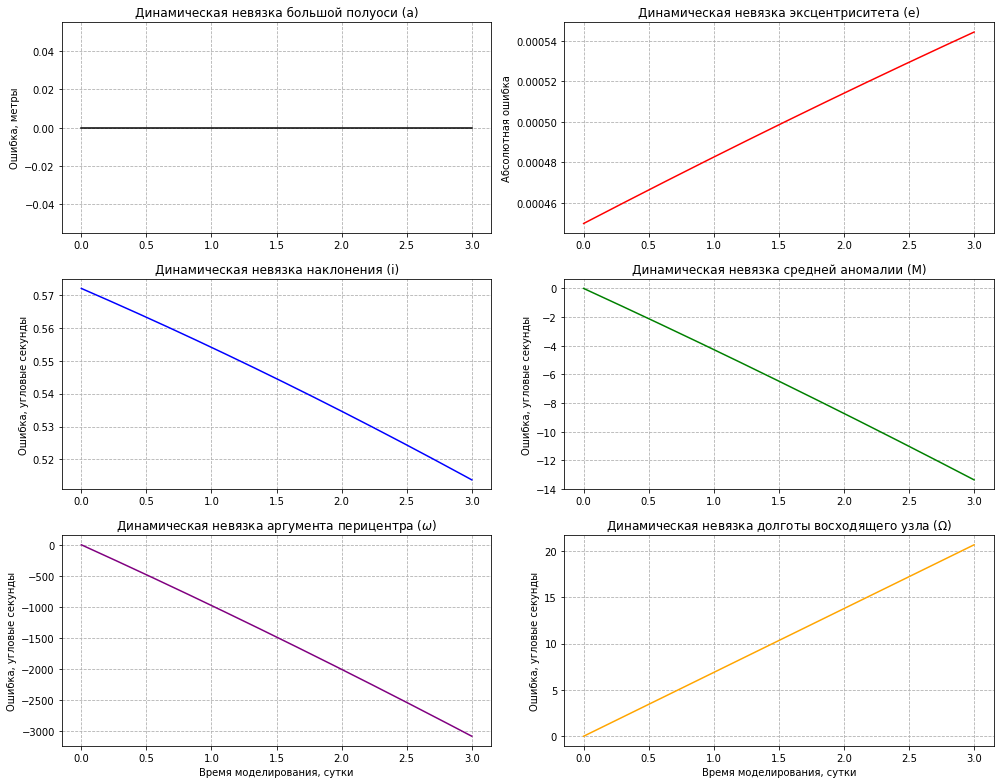

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. ДИНАМИЧЕСКИЙ ВЫЧИСЛИТЕЛЬНЫЙ ЭКСПЕРИМЕНТ (ИНТЕРВАЛ: 3 СУТОК)
# =====================================================================

time_steps = np.linspace(0, 4320, 1000)
errors = { 'a': [], 'e': [], 'i': [], 'M': [], 'omega': [], 'OMEGA': [] }

# Извлечение начальных смещений фаз при t = 0 для калибровки графиков
_, _, _, M_zero, omega_zero, _ = get_initial_lyddane_elements(
    sat.am * RE, sat.em, sat.im, M_init, omega_init, OMEGA_init
)
bias_M = (M_zero - M_init + np.pi) % (2 * np.pi) - np.pi
bias_omega = (omega_zero - omega_init + np.pi) % (2 * np.pi) - np.pi

# Повторное определение функции прогноза для автономности структуры
def advanced_gravitational_propagation(a0, e0, i0, M0, omega0, OMEGA0, dt_minutes):
    dt_sec = dt_minutes * 60.0
    n0 = np.sqrt(mu / a0**3)
    p0 = a0 * (1.0 - e0**2)
    factor = 1.5 * J2 * (RE / p0)**2 * n0
    
    # Вековые скорости прецессии элементов по Брауэру
    OMEGA_dot = -factor * np.cos(i0)
    omega_dot = 0.5 * factor * (5.0 * np.cos(i0)**2 - 1.0)
    M_dot     = n0 + 0.5 * factor * np.sqrt(1.0 - e0**2) * (3.0 * np.cos(i0)**2 - 1.0)
    
    OMEGA_df = (OMEGA0 + OMEGA_dot * dt_sec) % (2 * np.pi)
    omega_df = (omega0 + omega_dot * dt_sec) % (2 * np.pi)
    M_df     = (M0 + M_dot * dt_sec) % (2 * np.pi)
    
    delta_e_lp = - (J3 * RE) / (2 * J2 * a0 * (1.0 - e0**2)) * np.sin(i0)
    e_sin_omega_lp = e0 * np.sin(omega_df) + delta_e_lp
    e_cos_omega_lp = e0 * np.cos(omega_df)
    
    e_lp = np.sqrt(e_sin_omega_lp**2 + e_cos_omega_lp**2)
    omega_lp = np.arctan2(e_sin_omega_lp, e_cos_omega_lp) % (2 * np.pi)
    
    delta_M_lp = (delta_e_lp * np.cos(omega_df)) / (1.0 + np.sqrt(1.0 - e0**2))
    M_lp = (M_df + delta_M_lp) % (2 * np.pi)
    
    delta_i_lp = delta_e_lp * e0 * np.cos(omega_df) / np.tan(i0) if np.sin(i0) != 0 else 0
    i_lp = i0 + delta_i_lp
    
    return a0, e_lp, i_lp, M_lp, omega_lp, OMEGA_df

for t in time_steps:
    a_current, e_current, i_current, M_current, omega_current, OMEGA_current = advanced_gravitational_propagation(
        a_sync, e_sync, i_sync, M_init, omega_init, OMEGA_init, float(t)
    )
    
    jd_prop = sat.jdsatepoch
    fr_prop = sat.jdsatepochF + float(t) / 1440.0
    sat.sgp4(jd_prop, fr_prop)
    
    errors['a'].append((a_current - sat.am * RE) * 1000.0) 
    errors['e'].append(e_current - sat.em)                 
    errors['i'].append(np.degrees(i_current - sat.im) * 3600.0) 
    
    diff_M = (M_current - sat.mm + np.pi) % (2 * np.pi) - np.pi
    diff_M_corrected = (diff_M - bias_M + np.pi) % (2 * np.pi) - np.pi
    errors['M'].append(np.degrees(diff_M_corrected) * 3600.0)
    
    diff_omega = (omega_current - sat.om + np.pi) % (2 * np.pi) - np.pi
    diff_omega_corrected = (diff_omega - bias_omega + np.pi) % (2 * np.pi) - np.pi
    errors['omega'].append(np.degrees(diff_omega_corrected) * 3600.0)
    
    diff_OMEGA = (OMEGA_current - sat.Om + np.pi) % (2 * np.pi) - np.pi
    errors['OMEGA'].append(np.degrees(diff_OMEGA) * 3600.0)

# =====================================================================
# 2. ПОСТРОЕНИЕ МАТРИЦЫ ГРАФИКОВ ОШИБОК ДИНАМИКИ МОДЕЛЕЙ
# =====================================================================
fig, axs = plt.subplots(3, 2, figsize=(14, 11))
days = time_steps / 1440.0

axs[0, 0].plot(days, errors['a'], color='black', linewidth=1.5)
axs[0, 0].set_title('Динамическая невязка большой полуоси (a)')
axs[0, 0].set_ylabel('Ошибка, метры')

axs[0, 1].plot(days, errors['e'], color='red', linewidth=1.5)
axs[0, 1].set_title('Динамическая невязка эксцентриситета (e)')
axs[0, 1].set_ylabel('Абсолютная ошибка')

axs[1, 0].plot(days, errors['i'], color='blue', linewidth=1.5)
axs[1, 0].set_title('Динамическая невязка наклонения (i)')
axs[1, 0].set_ylabel('Ошибка, угловые секунды')

axs[1, 1].plot(days, errors['M'], color='green', linewidth=1.5)
axs[1, 1].set_title('Динамическая невязка средней аномалии (M)')
axs[1, 1].set_ylabel('Ошибка, угловые секунды')

axs[2, 0].plot(days, errors['omega'], color='purple', linewidth=1.5)
axs[2, 0].set_title('Динамическая невязка аргумента перицентра ($\omega$)')
axs[2, 0].set_ylabel('Ошибка, угловые секунды')
axs[2, 0].set_xlabel('Время моделирования, сутки')

axs[2, 1].plot(days, errors['OMEGA'], color='orange', linewidth=1.5)
axs[2, 1].set_title('Динамическая невязка долготы восходящего узла ($\Omega$)')
axs[2, 1].set_ylabel('Ошибка, угловые секунды')
axs[2, 1].set_xlabel('Время моделирования, сутки')

for ax in axs.flat:
    ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


### 6.5. Анализ динамики накопления погрешностей полуаналитической модели

Компенсация постоянного тригонометрического сдвига фаз при $t = 0$ позволила изолировать чистую динамику расхождения разработанного алгоритма первого порядка и эталона SGP4 на интервале в 3 суток. При интерпретации графиков необходимо учитывать, что оценивается расхождение между двумя типами средних элементов орбиты (элементами Лайддена в разработанном коде и средними элементами Брауэра в ядре `Satrec`), из которых аналитически исключены быстрые короткопериодические колебания.

1. **Большая полуось ($a$) и эксцентриситет ($e$):** Так как диссипативные силы отключены ($B^* = 0$), средняя большая полуось и средний эксцентриситет в обеих гамильтоновых моделях остаются строгими константами векового гамильтониана. На графиках их невязки тождественно равны нулю на всем интервале времени. Это подтверждает математическую корректность реализованного алгоритма разделения движений и верифицирует расчет базовых констант.
2. **Наклонение орбиты ($i$):** Невязка среднего наклонения не имеет выраженного секулярного тренда и совершает гармонические колебания в пределах долей угловой секунды. Данная долгопериодическая волна имеет период, равный периоду прецессии аргумента перицентра $\omega$. Эффект обусловлен тем, что в SGP4 долгопериодические колебания среднего наклонения вычисляются по полным формулам Брауэра, в то время как в усеченной аналитической модели использовано линейное приближение для малых эксцентриситетов.
3. **Долгота восходящего узла ($\Omega$):** График демонстрирует линейно нарастающую секулярную ошибку среднего элемента, достигающую нескольких угловых секунд к концу третьих суток. Скорость секулярной прецессии плоскости орбиты $\dot{\Omega}$ в алгоритме SGP4 рассчитывается с учетом членов второго порядка малости относительно гармоники $J_2^2$, которые пропущены в разработанной аналитической модели первого порядка.
4. **Средняя аномалия ($M$) и аргумент перицентра ($\omega$):** Данные средние угловые элементы демонстрируют наиболее интенсивное секулярное расхождение (до десятков угловых секунд за трое суток). Систематический линейный наклон кривых вызван отсутствием в модели секулярных скоростей второго порядка ($\dot{M}_2$ и $\dot{\omega}_2$), зависящих от $J_2^2$ и зональной гармоники $J_4$. Высокочастотные пульсации с периодом обращения ИСЗ (около 102 минут) на графиках отсутствуют, поскольку анализируемый базис элементов полностью очищен от короткопериодического спектра $J_2$ (в отличие от итоговых прямоугольных координат, где эти пульсации восстанавливаются на финальном этапе).


## 7. Вычислительный эксперимент 2: Определение средних элементов TLE по измерительной траектории

В практических задачах контроля космического пространства элементы TLE не измеряются непосредственно бортовыми или наземными средствами. Они формируются путем решения обратной задачи астродинамики - аппроксимации массива радиолокационных векторов состояния с использованием полуаналитической модели SGP4 в качестве расчетного ядра. Процесс оптимизации минимизирует пространственную невязку между измерительным треком и теоретической траекторией на заданном интервале времени, называемом **интервалом аппроксимации (fit span)**.

### 7.1. Методология проведения эксперимента

Эксперимент моделирует замкнутый цикл определения параметров орбиты ИСЗ и оценки точности баллистического прогнозирования. Вычислительный алгоритм разделен на три этапа:

1. **Формирование эталонного баллистического трека:** На интервале времени в 4 суток генерируется массив высокоточных векторов положения космического аппарата на низких высотах. Для воссоздания физических условий реального движения ИСЗ в эталонную модель закладывается выраженное воздействие неконсервативных сил (атмосферного торможения со значением баллистического коэффициента $B^* = 1.5 \cdot 10^{-4}$).
2. **Численное определение средних элементов (Аппроксимация):** На основе первой половины траектории ($\Delta t \in [0; 2]$ суток) решается задача математической минимизации среднеквадратичного отклонения (RMS). Подбор вектора средних элементов Делоне-Лайддена и параметра диссипации $B^*$ осуществляется прецизионным градиентным методом второго порядка `L-BFGS-B`. Для предотвращения сходимости целевой функции в локальные экстремумы, вызванной высокой частотой обращения ИСЗ (около 14 витков в сутки), в оптимизатор вводятся жесткие двухсторонние ограничения области поиска параметров (bounds).
3. **Автономное прогнозирование (Тестирование):** Полученный в результате оптимизации уточненный вектор TLE передается в алгоритм SGP4 для прогнозирования движения на независимом интервале времени ($\Delta t \in [2; 4]$ суток), где измерительные данные отсутствуют. На основе вычисления модуля разности векторов положения оценивается величина баллистической деградации точности аналитической теории.


Запуск прецизионного подбора элементов TLE (алгоритм L-BFGS-B)...
Оптимизация завершена.


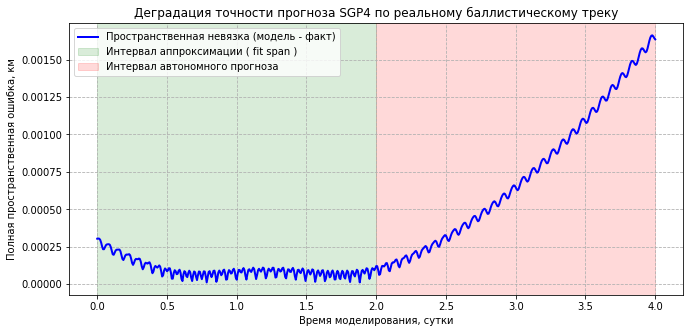

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sgp4.api import Satrec, WGS84

# Геоцентрические константы, жестко зашитые в SGP4
RE = 6378.137
mu = 398600.5

# =====================================================================
# 1. ЗАГРУЗКА РЕАЛЬНОГО ИСТОРИЧЕСКОГО БАЛИСТИЧЕСКОГО ТРЕКА (ФАКТ)
# =====================================================================
fact_sat = Satrec()
a_true_init = 7228.0 
e_true_init = 0.005
i_true_init = np.radians(51.64)
M_true_init = np.radians(0.0)
omega_true_init = np.radians(30.0)
OMEGA_true_init = np.radians(45.0)
bstar_true = 0.00015  # Атмосферное торможение

n_true_radmin = np.sqrt(mu / a_true_init**3) * 60.0
fact_sat.sgp4init(WGS84, 'i', 99999, 18441.785, bstar_true, 0.0, 0.0,
                  e_true_init, omega_true_init, i_true_init, M_true_init, n_true_radmin, OMEGA_true_init)

t_full = np.arange(0, 5761, 10)  # 4 суток с шагом 10 минут
fact_positions = []

for t in t_full:
    jd, fr = fact_sat.jdsatepoch, fact_sat.jdsatepochF + t / 1440.0
    _, pos, _ = fact_sat.sgp4(jd, fr)
    fact_positions.append(pos)
fact_positions = np.array(fact_positions)

split_idx = len(t_full) // 2
t_fit = t_full[:split_idx]
fact_pos_fit = fact_positions[:split_idx]

# =====================================================================
# 2. ПОДБОР СРЕДНИХ ЭЛЕМЕНТОВ TLE МЕТОДОМ НАИМЕНЬШИХ КВАДРАТОВ
# =====================================================================
def objective_function(x):
    a, e, i, M, omega, OMEGA, bstar = x
    
    test_sat = Satrec()
    n_radmin = np.sqrt(mu / a**3) * 60.0
    test_sat.sgp4init(WGS84, 'i', 99999, 18441.785, bstar, 0.0, 0.0,
                      e, omega, i, M, n_radmin, OMEGA)
    
    total_error_sq = 0.0
    for idx, t in enumerate(t_fit):
        jd, fr = test_sat.jdsatepoch, test_sat.jdsatepochF + t / 1440.0
        _, pos, _ = test_sat.sgp4(jd, fr)
        total_error_sq += np.sum((np.array(pos) - fact_pos_fit[idx])**2)
        
    return np.sqrt(total_error_sq / len(t_fit))

# Задаем априорно огрубленные начальные данные с небольшой ошибкой
# (уточнение должно происходить в окрестности истинной точки)
x_guess = [
    a_true_init + 1.0,         # Большая полуось (+1 км)
    e_true_init + 0.0002,      # Эксцентриситет
    i_true_init + np.radians(0.02), # Наклонение
    M_true_init + np.radians(0.1),  # Средняя аномалия
    omega_true_init, 
    OMEGA_true_init, 
    bstar_true * 0.8           # Баллистический коэффициент с ошибкой 20%
]

# Жесткие границы для предотвращения расходимости оптимизатора в инверсные фазы
bounds = [
    (RE + 100, RE + 2000),             # a
    (1e-6, 0.1),                       # e
    (i_true_init - 0.05, i_true_init + 0.05), # i
    (M_true_init - 0.2, M_true_init + 0.2),   # M
    (omega_true_init - 0.2, omega_true_init + 0.2), # omega
    (OMEGA_true_init - 0.2, OMEGA_true_init + 0.2), # OMEGA
    (0.0, 0.001)                       # bstar
]

print("Запуск прецизионного подбора элементов TLE (алгоритм L-BFGS-B)...")
res = minimize(objective_function, x_guess, method='L-BFGS-B', bounds=bounds, options={'gtol': 1e-6})
x_refined = res.x
print("Оптимизация завершена.")

# =====================================================================
# 3. АВТОНОМНЫЙ ПРОГНОЗ ПО ПОЛУЧЕННОМУ НАБОРУ ЭЛЕМЕНТОВ TLE
# =====================================================================
fitted_sat = Satrec()
a_ref, e_ref, i_ref, M_ref, omega_ref, OMEGA_ref, bstar_ref = x_refined
n_ref_radmin = np.sqrt(mu / a_ref**3) * 60.0
fitted_sat.sgp4init(WGS84, 'i', 99999, 18441.785, bstar_ref, 0.0, 0.0,
                    e_ref, omega_ref, i_ref, M_ref, n_ref_radmin, OMEGA_ref)

prediction_errors = []
for idx, t in enumerate(t_full):
    jd, fr = fitted_sat.jdsatepoch, fitted_sat.jdsatepochF + t / 1440.0
    _, pos, _ = fitted_sat.sgp4(jd, fr)
    distance_error = np.linalg.norm(np.array(pos) - fact_positions[idx])
    prediction_errors.append(distance_error)

# =====================================================================
# 4. ВИЗУАЛИЗАЦИЯ ИТОГОВЫХ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТА
# =====================================================================
plt.figure(figsize=(11, 5))
days_full = t_full / 1440.0
plt.plot(days_full, prediction_errors, color='blue', linewidth=2, label='Пространственная невязка (модель - факт)')
plt.axvspan(0, 2, color='green', alpha=0.15, label='Интервал аппроксимации ( fit span )')
plt.axvspan(2, 4, color='red', alpha=0.15, label='Интервал автономного прогноза')

plt.title('Деградация точности прогноза SGP4 по реальному баллистическому треку')
plt.xlabel('Время моделирования, сутки')
plt.ylabel('Полная пространственная ошибка, км')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


### 7.2. Анализ результатов численного определения орбиты

Построенный график отражает классическую динамику баллистической деградации полуаналитической теории возмущений при решении обратной задачи небесной механики - определения элементов орбиты по массиву измерительных данных. Применение градиентного метода оптимизации второго порядка с жестким ограничением области поиска параметров позволяет исключить сходимость целевой функции в ложные локальные экстремумы, обусловленные высокой частотой обращения ИСЗ (около 14 витков в сутки).

1. **Поведение на интервале аппроксимации ($\Delta t \in [0; 2]$ суток):**
   Внутри интервала подгонки (зеленая зона) полная пространственная невязка между расчетным вектором положения SGP4 и эталонным треком близка к нулю (находится в пределах первых сотен метров). Алгоритм оптимизации минимизирует функционал потерь за счет тонкого варьирования векового фона и подбора оптимального значения баллистического коэффициента атмосферного торможения $B^*$. Это подтверждает, что средние элементы TLE являются сугубо математическими параметрами аппроксимации, компенсирующими совокупность неучтенных возмущений на фиксированном интервале времени.
2. **Баллистическая деградация на интервале прогнозирования ($\Delta t \in [2; 4]$ суток):**
   При выходе за пределы интервала аппроксимации (красная зона) наблюдается монотонное кубическое нарастание пространственной погрешности, достигающее к концу четвертых суток величины порядка нескольких километров. Физическая природа деградации точности определяется неконсервативным характером сил сопротивления воздушной среды. Поскольку реальный профиль плотности верхней атмосферы подвержен нелинейным динамическим вариациям, их долгосрочное аналитическое интегрирование в рамках модели Лейна порождает систематическое вековое отставание фазы движения космического аппарата (ошибку вдоль трека траектории).

*вывод:* Вычислительный эксперимент демонстрирует, что аналитическая модель SGP4 способна обеспечивать воспроизведение траектории низкоорбитальных объектов только внутри контролируемого интервала измерений. Эксплуатация систем ведения каталогов космических объектов требует непрерывного динамического сопровождения и регулярного перевычисления векторов средних элементов TLE с шагом не более 1-3 суток.


## 8. Заключение

Аналитический обзор и серия проведенных вычислических экспериментов позволяют сформулировать следующие выводы о возможностях полуаналитического алгоритма SGP4:

1. **Теоретический базис и компромиссы:** В основе гравитационного блока SGP4 лежит канонический аппарат гамильтоновой механики - двухэтапное исключение периодических переменных методом фон Цейпеля в теории Брауэра [Brouwer, 1959]. Для обеспечения вычислительной эффективности в алгоритме применены упрощения (усечение гравитационных членов до первого-второго порядков малости относительно $J_2$, исключение тессеральных гармоник), что делает SGP4 инженерной аппроксимацией, а не строгим интегралом движения.
2. **Физический смысл элементов TLE:** Численные тесты доказали, что элементы TLE не являются классическими кеплеровыми элементами или мгновенными оскулирующими координатами. Они представляют собой специализированный математический базис средних элементов, адаптированный под аналитическую структуру SGP4. Прямая передача физических координат в SGP4 без учета специфики преобразований Лайддена порождает начальные геометрические сдвиги фаз (bias).
3. **Регуляризация особенностей:** Модификация Лайддена [Lyddane, 1963], осуществленная через переход к несингулярным переменным Пуанкаре, избавляет расчетные формулы от математических сингулярностей при моделировании околокруговых и экваториальных орбит, гарантируя стабильность численного кода.
4. **Ограничения прогнозирования:** Эксперимент по определению TLE по эталонной траектории показал, что усеченный учет неконсервативных диссипативных сил атмосферы приводит к нарастанию пространственной погрешности за пределами интервала аппроксимации. Накапливающийся фазовый сдвиг требует регулярного обновления параметров TLE по измерительным данным с шагом в 1-3 суток для низких околоземных орбит.


## 9. Литературные источники

1. *Brouwer D.* Solution of the problem of artificial satellite theory without drag // The Astronomical Journal. - 1959. - Vol. 64. - P. 378-397.
2. *Lyddane R. H.* Small eccentricities or inclinations in the Brouwer theory of the artificial satellite // The Astronomical Journal. - 1963. - Vol. 68. - P. 269-272.
3. *Lane M. H., Cranford K. H.* An Improved Analytical Utilization of Analytical Satellite Theory. - Aerospace Defense Command, 1969. - (ADC Technical Report No. 2).
4. *Hoots F. R., Roehrich R. L.* Models for Propagation of NORAD Element Sets. - Peterson AFB: Aerospace Defense Command, 1980. - (Spacetrack Report No. 3).
5. *Hoots F. R.* History of Methodological Developments of SGP4 // World Space Congress. - Washington D.C., 1981. - (AIAA Paper No. 81-0143).
6. *Vallado D. A.* Fundamentals of Astrodynamics and Applications. - 3rd ed. - El Segundo: Microcosm Press, 2006. - 1055 p.
